In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load Dataset
df = pd.read_csv(r"C:\Users\DELL 5490\Downloads\Titanic-Dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [4]:
#Check Missing Values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
#Handle Missing Values
#Fill Age with Median
df["Age"] = df["Age"].fillna(df["Age"].median())
#Fill Embarked with Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
#Drop Cabin Column
df.drop("Cabin", axis=1, inplace=True)
#Check again:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
#Convert Categorical Features into Numerical
#Label Encoding for Sex
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
#One-Hot Encoding for Embarked
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [7]:
#Normalize / Standardize Numerical Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])
print(df[["Age", "Fare"]].head())

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


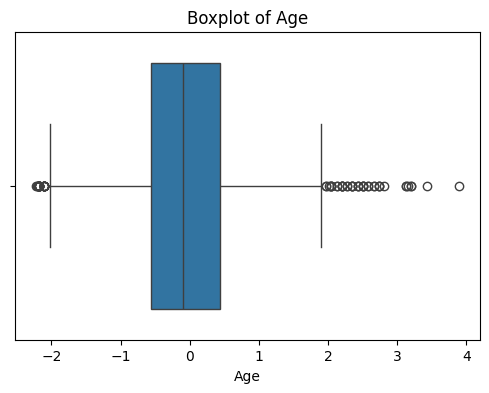

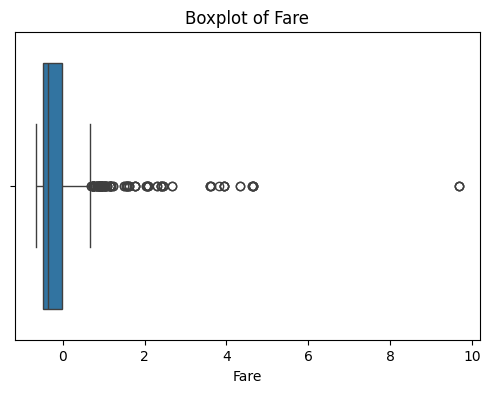

In [8]:
#Visualize Outliers Using Boxplots
#Age
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Boxplot of Age")
plt.show()
#Fare
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

In [9]:
#Remove Outliers Using IQR Method
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]
#Check dataset shape:
print(df.shape)

(775, 12)


In [10]:
#Save Cleaned Dataset
df.to_csv("Titanic_Cleaned.csv", index=False)
print("Dataset cleaned and saved successfully!")

Dataset cleaned and saved successfully!
